In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install -q --upgrade ipython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.0/626.0 kB 12.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 12.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.16.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [3]:
# Cell 1: Load extension after upgrading
%load_ext autoreload
%autoreload 2

In [4]:
import os
import sys

# Replace with your actual GitHub username and repository name
REPO_URL = "https://github.com/amitkhedar30/adversarial-attack-defense.git"
REPO_NAME = "adversarial-attack-defense"

# Clone if not already present in the Kaggle working directory
if not os.path.exists(REPO_NAME):
    !git clone {REPO_URL}

# Add repository root to Python path so custom imports work
if f"/kaggle/working/{REPO_NAME}" not in sys.path:
    sys.path.append(f"/kaggle/working/{REPO_NAME}")

print("Repository is ready!")

Repository is ready!


In [5]:
# Pull the latest code from GitHub
!cd {REPO_NAME} && git pull

# Install project dependencies
!pip install -q -r {REPO_NAME}/requirements.txt

Already up to date.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 22.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.3/92.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 13.1 MB/s eta 0:00:00


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

# Import your team's custom modules from the GitHub repository
from models.classifier import get_cifar10_resnet18
from utils.dataset import get_dataloaders
from utils.checkpoint import save_checkpoint, load_latest_checkpoint

# 1. Configuration & Hyperparameters
EPOCHS = 50
BATCH_SIZE = 128
LEARNING_RATE = 0.1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Running on device: {DEVICE}")

# 2. Initialize Data, Model, and Optimizer
train_loader, test_loader = get_dataloaders(batch_size=BATCH_SIZE)
model = get_cifar10_resnet18(num_classes=10).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# 3. Handle Checkpointing (Resumes automatically if Kaggle crashes)
start_epoch = load_latest_checkpoint(model, optimizer, "Standard_ResNet18")

# 4. The Standard Training Loop
print("[*] Starting standard baseline training...")
for epoch in range(start_epoch, EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    scheduler.step()
    
    # Calculate Epoch Metrics
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")
    
    # Save checkpoint at the end of each epoch
    save_checkpoint(model, optimizer, epoch, "Standard_ResNet18")

# 5. Save Final Export Weights
torch.save(model.state_dict(), "/kaggle/working/resnet18_standard_cifar10.pt")
print("[*] Baseline training complete! Final model saved.")

[*] Running on device: cuda


100%|██████████| 170M/170M [20:38<00:00, 138kB/s]  


[*] No existing Standard_ResNet18 checkpoints found. Starting from scratch.
[*] Starting standard baseline training...
Epoch [1/50] | Loss: 1.9499 | Accuracy: 29.88%
[*] Saved Standard_ResNet18 checkpoint to /kaggle/working/checkpoints/Standard_ResNet18_epoch_0.pt
Epoch [2/50] | Loss: 1.4213 | Accuracy: 47.85%
[*] Saved Standard_ResNet18 checkpoint to /kaggle/working/checkpoints/Standard_ResNet18_epoch_1.pt
Epoch [3/50] | Loss: 1.1181 | Accuracy: 59.98%
[*] Saved Standard_ResNet18 checkpoint to /kaggle/working/checkpoints/Standard_ResNet18_epoch_2.pt
Epoch [4/50] | Loss: 0.9212 | Accuracy: 67.45%
[*] Saved Standard_ResNet18 checkpoint to /kaggle/working/checkpoints/Standard_ResNet18_epoch_3.pt
Epoch [5/50] | Loss: 0.7564 | Accuracy: 73.58%
[*] Saved Standard_ResNet18 checkpoint to /kaggle/working/checkpoints/Standard_ResNet18_epoch_4.pt
Epoch [6/50] | Loss: 0.6508 | Accuracy: 77.34%
[*] Saved Standard_ResNet18 checkpoint to /kaggle/working/checkpoints/Standard_ResNet18_epoch_5.pt
Epoch

In [7]:
import torch
from models.classifier import get_cifar10_resnet18
from utils.dataset import get_dataloaders
from attacks.whitebox import fgsm_attack, pgd_attack

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128

# 1. Load the Test Data and Model
_, test_loader = get_dataloaders(batch_size=BATCH_SIZE)
model = get_cifar10_resnet18(num_classes=10)

# Load the weights you just trained!
model.load_state_dict(torch.load("/kaggle/working/resnet18_standard_cifar10.pt"))
model.to(DEVICE)
model.eval() # Crucial: Set model to evaluation mode

# 2. Evaluation Metrics
correct_clean = 0
correct_fgsm = 0
correct_pgd = 0
total = 0

print("[*] Evaluating baseline model against attacks...")
print("This may take a minute or two as it generates attacks...")

for inputs, labels in test_loader:
    inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
    total += labels.size(0)
    
    # A. Clean Accuracy (No Attack)
    with torch.no_grad():
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        correct_clean += predicted.eq(labels).sum().item()
        
    # B. FGSM Attack (epsilon = 8/255 is the standard benchmark)
    inputs_fgsm = fgsm_attack(model, inputs, labels, epsilon=8/255)
    with torch.no_grad():
        outputs_fgsm = model(inputs_fgsm)
        _, pred_fgsm = outputs_fgsm.max(1)
        correct_fgsm += pred_fgsm.eq(labels).sum().item()
        
    # C. PGD Attack (iters=10 is the standard quick-test)
    inputs_pgd = pgd_attack(model, inputs, labels, epsilon=8/255, alpha=2/255, iters=10)
    with torch.no_grad():
        outputs_pgd = model(inputs_pgd)
        _, pred_pgd = outputs_pgd.max(1)
        correct_pgd += pred_pgd.eq(labels).sum().item()

# 3. Print the Devastation
print("-" * 30)
print(f"Clean Test Accuracy: {100. * correct_clean / total:.2f}%")
print(f"FGSM Accuracy:       {100. * correct_fgsm / total:.2f}%")
print(f"PGD Accuracy:        {100. * correct_pgd / total:.2f}%")
print("-" * 30)

[*] Evaluating baseline model against attacks...
This may take a minute or two as it generates attacks...
------------------------------
Clean Test Accuracy: 94.44%
FGSM Accuracy:       33.77%
PGD Accuracy:        0.03%
------------------------------


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from models.classifier import get_cifar10_resnet18
from utils.dataset import get_dataloaders
from utils.checkpoint import save_checkpoint, load_latest_checkpoint
from attacks.whitebox import pgd_attack

# 1. Configuration & Setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
EPOCHS = 50

print(f"[*] Starting PGD Adversarial Training on device: {DEVICE}")

# 2. Data Loaders & Model Initialization
train_loader, test_loader = get_dataloaders(batch_size=BATCH_SIZE)
model_robust = get_cifar10_resnet18(num_classes=10).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_robust.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# 3. Resume Checkpoint Logic (Fixed function signature)
start_epoch = load_latest_checkpoint(model_robust, optimizer, "Robust_ResNet18")

# 4. PGD Adversarial Training Loop
for epoch in range(start_epoch, EPOCHS):
    model_robust.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        # DYNAMIC ATTACK: Generate PGD perturbations on the training batch
        adv_inputs = pgd_attack(
            model_robust, 
            inputs, 
            labels, 
            epsilon=8/255, 
            alpha=2/255, 
            iters=10
        )
        
        # Forward & Backward pass on ADVERSARIAL inputs
        optimizer.zero_grad()
        outputs = model_robust(adv_inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    scheduler.step()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Robust Loss: {epoch_loss:.4f} | Robust Acc: {epoch_acc:.2f}%")
    
    # Save checkpoint (Fixed function signature)
    save_checkpoint(model_robust, optimizer, epoch, "Robust_ResNet18")

# 5. Export Final Robust Model Weights
torch.save(model_robust.state_dict(), "/kaggle/working/resnet18_robust_pgd_cifar10.pt")
print("[*] PGD Adversarial Training complete! Final robust model saved.")

[*] Starting PGD Adversarial Training on device: cuda
[*] Resuming Robust_ResNet18 from epoch 25 (File: /kaggle/working/checkpoints/Robust_ResNet18_epoch_24.pt)
Epoch [26/50] | Robust Loss: 1.3455 | Robust Acc: 48.88%
[*] Saved Robust_ResNet18 checkpoint to /kaggle/working/checkpoints/Robust_ResNet18_epoch_25.pt
Epoch [27/50] | Robust Loss: 1.3417 | Robust Acc: 48.81%
[*] Saved Robust_ResNet18 checkpoint to /kaggle/working/checkpoints/Robust_ResNet18_epoch_26.pt
Epoch [28/50] | Robust Loss: 1.3351 | Robust Acc: 49.15%
[*] Saved Robust_ResNet18 checkpoint to /kaggle/working/checkpoints/Robust_ResNet18_epoch_27.pt
Epoch [29/50] | Robust Loss: 1.3321 | Robust Acc: 49.11%
[*] Saved Robust_ResNet18 checkpoint to /kaggle/working/checkpoints/Robust_ResNet18_epoch_28.pt
Epoch [30/50] | Robust Loss: 1.3216 | Robust Acc: 49.54%
[*] Saved Robust_ResNet18 checkpoint to /kaggle/working/checkpoints/Robust_ResNet18_epoch_29.pt
Epoch [31/50] | Robust Loss: 1.3204 | Robust Acc: 49.34%
[*] Saved Robust_

In [7]:
import torch
from models.classifier import get_cifar10_resnet18
from utils.dataset import get_dataloaders
from attacks.whitebox import fgsm_attack, pgd_attack

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128

# 1. Load Data & Robust Model
_, test_loader = get_dataloaders(batch_size=BATCH_SIZE)
model_robust = get_cifar10_resnet18(num_classes=10)
model_robust.load_state_dict(torch.load("/kaggle/working/resnet18_robust_pgd_cifar10.pt"))
model_robust.to(DEVICE)
model_robust.eval()

correct_clean = 0
correct_fgsm = 0
correct_pgd = 0
total = 0

print("[*] Evaluating ROBUST model (Model B) against attacks...")

for inputs, labels in test_loader:
    inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
    total += labels.size(0)
    
    # Clean Accuracy
    with torch.no_grad():
        outputs = model_robust(inputs)
        _, predicted = outputs.max(1)
        correct_clean += predicted.eq(labels).sum().item()
        
    # FGSM Attack
    inputs_fgsm = fgsm_attack(model_robust, inputs, labels, epsilon=8/255)
    with torch.no_grad():
        outputs_fgsm = model_robust(inputs_fgsm)
        _, pred_fgsm = outputs_fgsm.max(1)
        correct_fgsm += pred_fgsm.eq(labels).sum().item()
        
    # PGD Attack
    inputs_pgd = pgd_attack(model_robust, inputs, labels, epsilon=8/255, alpha=2/255, iters=10)
    with torch.no_grad():
        outputs_pgd = model_robust(inputs_pgd)
        _, pred_pgd = outputs_pgd.max(1)
        correct_pgd += pred_pgd.eq(labels).sum().item()

print("=" * 40)
print(f"Robust Model Clean Accuracy: {100. * correct_clean / total:.2f}%")
print(f"Robust Model FGSM Accuracy:  {100. * correct_fgsm / total:.2f}%")
print(f"Robust Model PGD Accuracy:   {100. * correct_pgd / total:.2f}%")
print("=" * 40)

[*] Evaluating ROBUST model (Model B) against attacks...
Robust Model Clean Accuracy: 79.63%
Robust Model FGSM Accuracy:  53.83%
Robust Model PGD Accuracy:   49.29%


In [8]:
!pip install -q statsmodels

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from scipy.stats import norm
from statsmodels.stats.proportion import proportion_confint
from models.classifier import get_cifar10_resnet18
from utils.dataset import get_dataloaders

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
EPOCHS = 30
SIGMA = 0.25 # Industry standard noise level for CIFAR-10

print(f"[*] Training Gaussian-Augmented Model (sigma={SIGMA})...")
train_loader, test_loader = get_dataloaders(batch_size=BATCH_SIZE)
model_gaussian = get_cifar10_resnet18(num_classes=10).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_gaussian.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

for epoch in range(EPOCHS):
    model_gaussian.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        # ADD GAUSSIAN NOISE (The Cohen et al. requirement)
        noise = torch.randn_like(inputs) * SIGMA
        noisy_inputs = inputs + noise
        
        optimizer.zero_grad()
        outputs = model_gaussian(noisy_inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    scheduler.step()
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Noise Loss: {running_loss/len(train_loader):.4f} | Acc: {100.*correct/total:.2f}%")

torch.save(model_gaussian.state_dict(), "/kaggle/working/resnet18_gaussian_cifar10.pt")
print("[*] Gaussian model saved!")

# --- DEFINE THE SMOOTHING CLASS ---
class Smooth:
    ABSTAIN = -1
    def __init__(self, base_classifier: torch.nn.Module, num_classes: int, sigma: float):
        self.base_classifier = base_classifier
        self.num_classes = num_classes
        self.sigma = sigma

    def certify(self, x: torch.Tensor, n0: int, n: int, alpha: float, batch_size: int) -> tuple[int, float]:
        self.base_classifier.eval()
        counts0 = self._sample_noise(x, n0, batch_size)
        c_hat_A = counts0.argmax().item()

        counts = self._sample_noise(x, n, batch_size)
        nA = counts[c_hat_A].item()

        pA_lower = proportion_confint(nA, n, alpha=2 * alpha, method="beta")[0]

        if pA_lower > 0.5:
            radius = self.sigma * norm.ppf(pA_lower)
            return c_hat_A, radius
        else:
            return self.ABSTAIN, 0.0

    def _sample_noise(self, x: torch.Tensor, num_samples: int, batch_size: int) -> np.ndarray:
        device = next(self.base_classifier.parameters()).device
        x = x.to(device)
        counts = np.zeros(self.num_classes, dtype=int)
        
        with torch.no_grad():
            for _ in range(int(np.ceil(num_samples / batch_size))):
                this_batch_size = min(batch_size, num_samples)
                num_samples -= this_batch_size
                batch = x.repeat((this_batch_size, 1, 1, 1))
                noise = torch.randn_like(batch) * self.sigma
                noisy_batch = batch + noise
                
                outputs = self.base_classifier(noisy_batch)
                predictions = outputs.argmax(dim=1).cpu().numpy()
                for pred in predictions:
                    counts[pred] += 1
        return counts

[*] Training Gaussian-Augmented Model (sigma=0.25)...
Epoch [1/30] | Noise Loss: 2.1092 | Acc: 24.09%
Epoch [2/30] | Noise Loss: 1.6109 | Acc: 40.14%
Epoch [3/30] | Noise Loss: 1.4440 | Acc: 46.95%
Epoch [4/30] | Noise Loss: 1.3287 | Acc: 51.92%
Epoch [5/30] | Noise Loss: 1.2285 | Acc: 55.72%
Epoch [6/30] | Noise Loss: 1.1508 | Acc: 58.73%
Epoch [7/30] | Noise Loss: 1.0898 | Acc: 61.12%
Epoch [8/30] | Noise Loss: 1.0435 | Acc: 62.99%
Epoch [9/30] | Noise Loss: 1.0013 | Acc: 64.62%
Epoch [10/30] | Noise Loss: 0.9729 | Acc: 65.63%
Epoch [11/30] | Noise Loss: 0.9420 | Acc: 66.87%
Epoch [12/30] | Noise Loss: 0.9149 | Acc: 67.73%
Epoch [13/30] | Noise Loss: 0.8959 | Acc: 68.49%
Epoch [14/30] | Noise Loss: 0.8693 | Acc: 69.26%
Epoch [15/30] | Noise Loss: 0.8404 | Acc: 70.41%
Epoch [16/30] | Noise Loss: 0.8172 | Acc: 71.25%
Epoch [17/30] | Noise Loss: 0.7936 | Acc: 71.98%
Epoch [18/30] | Noise Loss: 0.7623 | Acc: 72.90%
Epoch [19/30] | Noise Loss: 0.7420 | Acc: 74.00%
Epoch [20/30] | Noise Lo

In [10]:
import pandas as pd

# 1. Certification Hyperparameters
N0 = 100       # Samples to guess the class
N = 10000      # Samples to estimate the lower bound (reduced from 100k for speed)
ALPHA = 0.001  # 99.9% confidence
SUBSET_SIZE = 250 # Number of images to certify

print(f"[*] Certifying {SUBSET_SIZE} images with N={N}, alpha={ALPHA}, sigma={SIGMA}")

# 2. Initialize Smoothed Classifier
model_gaussian.eval()
smoothed_classifier = Smooth(model_gaussian, num_classes=10, sigma=SIGMA)
_, test_loader = get_dataloaders(batch_size=1) 

results = []

# 3. Run Certification Loop
for i, (x, label) in enumerate(test_loader):
    if i >= SUBSET_SIZE: 
        break
        
    pred, radius = smoothed_classifier.certify(x[0], N0, N, ALPHA, batch_size=256)
    correct = int(pred == label.item())
    
    results.append({
        "image_idx": i,
        "label": label.item(),
        "prediction": pred,
        "correct": correct,
        "radius": radius
    })
    
    if (i + 1) % 10 == 0:
        print(f"Certified {i + 1}/{SUBSET_SIZE} | Last Radius: {radius:.4f} | Correct: {bool(correct)}")

# 4. Export Data
df = pd.DataFrame(results)
df.to_csv("/kaggle/working/certification_radii.csv", index=False)
print("\n[*] SUCCESS: certification_radii.csv saved! Phase 2 is complete.")

[*] Certifying 250 images with N=10000, alpha=0.001, sigma=0.25
Certified 10/250 | Last Radius: 0.4067 | Correct: True
Certified 20/250 | Last Radius: 0.7785 | Correct: True
Certified 30/250 | Last Radius: 0.7785 | Correct: True
Certified 40/250 | Last Radius: 0.7276 | Correct: True
Certified 50/250 | Last Radius: 0.3190 | Correct: True
Certified 60/250 | Last Radius: 0.1459 | Correct: True
Certified 70/250 | Last Radius: 0.4903 | Correct: True
Certified 80/250 | Last Radius: 0.7785 | Correct: True
Certified 90/250 | Last Radius: 0.7996 | Correct: True
Certified 100/250 | Last Radius: 0.7996 | Correct: True
Certified 110/250 | Last Radius: 0.7996 | Correct: True
Certified 120/250 | Last Radius: 0.2189 | Correct: False
Certified 130/250 | Last Radius: 0.0200 | Correct: False
Certified 140/250 | Last Radius: 0.2816 | Correct: False
Certified 150/250 | Last Radius: 0.4937 | Correct: True
Certified 160/250 | Last Radius: 0.6100 | Correct: True
Certified 170/250 | Last Radius: 0.1351 | Corr

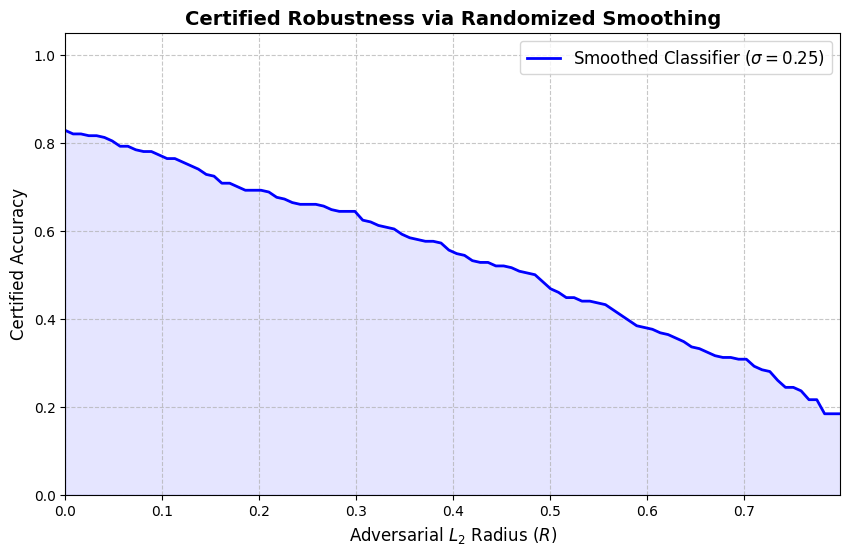

[*] Plot saved as certified_accuracy_curve.png! Phase 2 is 100% complete.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the certification data
df = pd.read_csv("/kaggle/working/certification_radii.csv")

# 2. Define the radii thresholds to plot (from 0 up to the maximum radius found)
max_radius = df['radius'].max()
radii_thresholds = np.linspace(0, max_radius, 100)
certified_accuracies = []

# 3. Calculate certified accuracy at each threshold
total_images = len(df)
for r in radii_thresholds:
    # A prediction is certified at radius r ONLY IF it was correct AND its certified radius >= r
    robust_count = ((df['correct'] == True) & (df['radius'] >= r)).sum()
    certified_accuracies.append(robust_count / total_images)

# 4. Plot the curve
plt.figure(figsize=(10, 6))
plt.plot(radii_thresholds, certified_accuracies, linewidth=2, color='blue', label=r'Smoothed Classifier ($\sigma=0.25$)')

plt.fill_between(radii_thresholds, certified_accuracies, alpha=0.1, color='blue')
plt.xlabel("Adversarial $L_2$ Radius ($R$)", fontsize=12)
plt.ylabel("Certified Accuracy", fontsize=12)
plt.title("Certified Robustness via Randomized Smoothing", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 1.05)
plt.xlim(0, max_radius)
plt.legend(loc='upper right', fontsize=12)

# Save the plot for your report/dashboard
plt.savefig("/kaggle/working/certified_accuracy_curve.png", dpi=300, bbox_inches='tight')
plt.show()

print("[*] Plot saved as certified_accuracy_curve.png! Phase 2 is 100% complete.")

In [12]:
import torch
import torch.optim as optim

def cw_l2_attack(model, images, labels, targeted=False, c=1e-4, kappa=0, max_iters=1000, lr=0.01):
    """
    Carlini & Wagner L2 Attack
    Optimizes the perturbation directly to minimize L2 norm while causing misclassification.
    """
    images = images.clone().detach().to(images.device)
    labels = labels.clone().detach().to(labels.device)
    
    # C&W optimizes over the arctanh space to keep pixels bounded between 0 and 1
    def atanh(x):
        return 0.5 * torch.log((1 + x) / (1 - x))
    
    # Map images to arctanh space
    # (Assuming images are in [0, 1]. If using standard normalization, this needs adjustment)
    modifier = torch.zeros_like(images, requires_grad=True).to(images.device)
    
    optimizer = optim.Adam([modifier], lr=lr)
    
    for step in range(max_iters):
        optimizer.zero_grad()
        
        # Calculate adversarial image in valid pixel space
        adv_images = 0.5 * (torch.tanh(modifier + atanh(images * 0.999999)) + 1)
        
        # Calculate L2 distance
        l2_dist = torch.sum((adv_images - images) ** 2, dim=[1, 2, 3])
        
        # Calculate the classification loss
        outputs = model(adv_images)
        real_logits = outputs.gather(1, labels.unsqueeze(1)).squeeze(1)
        
        # Get the highest prediction other than the true label
        outputs_clone = outputs.clone()
        outputs_clone.scatter_(1, labels.unsqueeze(1), -float('inf'))
        other_logits = outputs_clone.max(1)[0]
        
        if targeted:
            f_loss = torch.clamp(other_logits - real_logits + kappa, min=0)
        else:
            f_loss = torch.clamp(real_logits - other_logits + kappa, min=0)
            
        # Combine L2 distance and classification loss
        loss = torch.mean(l2_dist + c * f_loss)
        
        loss.backward()
        optimizer.step()
        
    # Return the final adversarial images
    with torch.no_grad():
        final_adv_images = 0.5 * (torch.tanh(modifier + atanh(images * 0.999999)) + 1)
        
    return final_adv_images

print("[*] C&W L2 Attack function loaded!")

[*] C&W L2 Attack function loaded!


In [13]:
import torch
from models.classifier import get_cifar10_resnet18
from utils.dataset import get_dataloaders

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load Baseline Model
model_baseline = get_cifar10_resnet18(num_classes=10)
model_baseline.load_state_dict(torch.load("/kaggle/working/resnet18_standard_cifar10.pt"))
model_baseline.to(DEVICE)
model_baseline.eval()

# 2. Get a single small batch (C&W is computationally heavy)
_, test_loader = get_dataloaders(batch_size=16)
inputs, labels = next(iter(test_loader))
inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

print("[*] Running C&W Attack on a single batch (16 images)...")
print("    (This might take 30-60 seconds due to 1000 optimization steps)")

# 3. Clean Evaluation
with torch.no_grad():
    clean_outputs = model_baseline(inputs)
    _, clean_preds = clean_outputs.max(1)
    clean_acc = clean_preds.eq(labels).sum().item() / labels.size(0)

# 4. Generate C&W Attack
adv_inputs = cw_l2_attack(model_baseline, inputs, labels, c=1e-3, max_iters=1000)

# 5. Adversarial Evaluation
with torch.no_grad():
    adv_outputs = model_baseline(adv_inputs)
    _, adv_preds = adv_outputs.max(1)
    adv_acc = adv_preds.eq(labels).sum().item() / labels.size(0)
    
    # Calculate how much noise C&W actually added (L2 norm)
    l2_distances = torch.sqrt(torch.sum((adv_inputs - inputs) ** 2, dim=[1, 2, 3]))
    avg_l2 = l2_distances.mean().item()

print("-" * 40)
print(f"Clean Batch Accuracy: {clean_acc * 100:.2f}%")
print(f"C&W Batch Accuracy:   {adv_acc * 100:.2f}%")
print(f"Average L2 Noise:     {avg_l2:.4f}")
print("-" * 40)

[*] Running C&W Attack on a single batch (16 images)...
    (This might take 30-60 seconds due to 1000 optimization steps)
----------------------------------------
Clean Batch Accuracy: 100.00%
C&W Batch Accuracy:   87.50%
Average L2 Noise:     0.1180
----------------------------------------


In [14]:
import torch
import pandas as pd
import numpy as np
from models.classifier import get_cifar10_resnet18
from utils.dataset import get_dataloaders
from scipy.stats import norm
from statsmodels.stats.proportion import proportion_confint

# 1. Setup & Load Smoothed Model
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SIGMA = 0.25

model_gaussian = get_cifar10_resnet18(num_classes=10)
model_gaussian.load_state_dict(torch.load("/kaggle/working/resnet18_gaussian_cifar10.pt"))
model_gaussian.to(DEVICE)
model_gaussian.eval()

# Re-define Smooth class briefly for standalone prediction
class SmoothPredictor:
    def __init__(self, base_classifier, num_classes, sigma):
        self.base_classifier = base_classifier
        self.num_classes = num_classes
        self.sigma = sigma
        
    def predict(self, x: torch.Tensor, n: int, batch_size: int):
        self.base_classifier.eval()
        counts = np.zeros(self.num_classes, dtype=int)
        x = x.to(DEVICE)
        
        with torch.no_grad():
            for _ in range(int(np.ceil(n / batch_size))):
                this_batch_size = min(batch_size, n)
                n -= this_batch_size
                batch = x.repeat((this_batch_size, 1, 1, 1))
                noise = torch.randn_like(batch) * self.sigma
                outputs = self.base_classifier(batch + noise)
                preds = outputs.argmax(dim=1).cpu().numpy()
                for p in preds: counts[p] += 1
        return counts.argmax().item()

smoothed_model = SmoothPredictor(model_gaussian, 10, SIGMA)

# 2. Pick a strongly certified image from Phase 2
df = pd.read_csv("/kaggle/working/certification_radii.csv")
# Find an image that was correctly classified and has a large certified radius
robust_images = df[(df['correct'] == True) & (df['radius'] > 0.4)]
target_idx = robust_images.iloc[0]['image_idx']
certified_R = robust_images.iloc[0]['radius']
true_label = robust_images.iloc[0]['label']

print(f"[*] SANITY TEST: Image Index {target_idx}")
print(f"[*] Certified Safe Radius (R): {certified_R:.4f}")
print(f"[*] True Label: {true_label}")
print("-" * 40)

# 3. Retrieve the actual image
_, test_loader = get_dataloaders(batch_size=1)
for i, (x, y) in enumerate(test_loader):
    if i == target_idx:
        clean_image = x.to(DEVICE)
        break

# 4. Generate C&W Attack (High 'c' to ensure it tries hard to attack)
print("[*] Generating C&W Attack to find an adversarial direction...")
adv_image = cw_l2_attack(model_gaussian, clean_image, y.to(DEVICE), c=0.5, max_iters=500)

# 5. Scale the perturbation to be STRICTLY LESS than the certified radius R
perturbation = adv_image - clean_image
current_l2 = torch.sqrt(torch.sum(perturbation ** 2)).item()

# We scale it to 95% of R so it is definitively inside the certified safe zone
scaling_factor = (certified_R * 0.95) / (current_l2 + 1e-8) 
bounded_perturbation = perturbation * scaling_factor
bounded_adv_image = torch.clamp(clean_image + bounded_perturbation, 0, 1)

final_l2 = torch.sqrt(torch.sum((bounded_adv_image - clean_image) ** 2)).item()
print(f"[*] Scaled Attack L2 Norm: {final_l2:.4f} (Strictly < {certified_R:.4f})")

# 6. The Moment of Truth: Can it fool the smoothed classifier?
print("[*] Passing bounded attack to the Smoothed Classifier (N=1000)...")
robust_pred = smoothed_model.predict(bounded_adv_image[0], n=1000, batch_size=256)

print("-" * 40)
print(f"[*] Smoothed Model Prediction: {robust_pred}")
if robust_pred == true_label:
    print("[*] RESULT: SUCCESS! The certified boundary held. Prediction did not flip.")
else:
    print("[*] RESULT: FAILURE. The mathematical bound was broken.")
print("-" * 40)

[*] SANITY TEST: Image Index 0.0
[*] Certified Safe Radius (R): 0.5864
[*] True Label: 3.0
----------------------------------------
[*] Generating C&W Attack to find an adversarial direction...
[*] Scaled Attack L2 Norm: 0.5570 (Strictly < 0.5864)
[*] Passing bounded attack to the Smoothed Classifier (N=1000)...
----------------------------------------
[*] Smoothed Model Prediction: 3
[*] RESULT: SUCCESS! The certified boundary held. Prediction did not flip.
----------------------------------------


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import mobilenet_v2
import pandas as pd
from models.classifier import get_cifar10_resnet18
from utils.dataset import get_dataloaders
from attacks.whitebox import pgd_attack

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
EPOCHS_SUBSTITUTE = 10  # Just enough to learn a decision boundary

print("[*] Phase 4: Building the Transferability Matrix")
train_loader, test_loader = get_dataloaders(batch_size=BATCH_SIZE)

# 1. Train the Substitute Model (MobileNetV2)
print("\n[*] Training Substitute Model (MobileNetV2)...")
model_substitute = mobilenet_v2(num_classes=10).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_substitute.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_SUBSTITUTE)

for epoch in range(EPOCHS_SUBSTITUTE):
    model_substitute.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model_substitute(inputs), labels)
        loss.backward()
        optimizer.step()
    scheduler.step()
    print(f"    Epoch {epoch+1}/{EPOCHS_SUBSTITUTE} complete.")

model_substitute.eval()

# 2. Load Your Baseline Target (ResNet18)
print("\n[*] Loading Target Model (Baseline ResNet18)...")
model_target = get_cifar10_resnet18(num_classes=10)
model_target.load_state_dict(torch.load("/kaggle/working/resnet18_standard_cifar10.pt"))
model_target.to(DEVICE)
model_target.eval()

# 3. Cross-Attack Evaluation Logic
def evaluate_transfer(source_model, target_model, dataloader, attack_name="PGD"):
    correct_clean, correct_adv, total = 0, 0, 0
    
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        total += labels.size(0)
        
        # Target's Clean Accuracy
        with torch.no_grad():
            _, clean_preds = target_model(inputs).max(1)
            correct_clean += clean_preds.eq(labels).sum().item()
            
        # Generate Attack on SOURCE
        adv_inputs = pgd_attack(source_model, inputs, labels, epsilon=8/255, alpha=2/255, iters=10)
        
        # Test Attack on TARGET
        with torch.no_grad():
            _, adv_preds = target_model(adv_inputs).max(1)
            correct_adv += adv_preds.eq(labels).sum().item()
            
        # Break early for speed (test on a subset of 5 batches)
        if total >= 5 * BATCH_SIZE:
            break
            
    return (correct_clean / total) * 100, (correct_adv / total) * 100

# 4. Generate the Matrix
print("\n[*] Running Cross-Attacks...")

# A. White-Box: ResNet attacks ResNet
_, resnet_to_resnet = evaluate_transfer(model_target, model_target, test_loader)
# B. Black-Box: MobileNet attacks ResNet
_, mobilenet_to_resnet = evaluate_transfer(model_substitute, model_target, test_loader)
# C. Black-Box: ResNet attacks MobileNet
_, resnet_to_mobilenet = evaluate_transfer(model_target, model_substitute, test_loader)
# D. White-Box: MobileNet attacks MobileNet
clean_mobile, mobilenet_to_mobilenet = evaluate_transfer(model_substitute, model_substitute, test_loader)

# 5. Save and Display
matrix = pd.DataFrame({
    "Target: ResNet18": [resnet_to_resnet, mobilenet_to_resnet],
    "Target: MobileNetV2": [resnet_to_mobilenet, mobilenet_to_mobilenet]
}, index=["Source: ResNet18", "Source: MobileNetV2"])

matrix.to_csv("/kaggle/working/transferability_matrix.csv")

print("\n" + "="*45)
print("       TRANSFERABILITY MATRIX (Accuracy %)")
print("="*45)
print(matrix.round(2))
print("="*45)
print("[*] Saved to transferability_matrix.csv!")

[*] Phase 4: Building the Transferability Matrix

[*] Training Substitute Model (MobileNetV2)...
    Epoch 1/10 complete.
    Epoch 2/10 complete.
    Epoch 3/10 complete.
    Epoch 4/10 complete.
    Epoch 5/10 complete.
    Epoch 6/10 complete.
    Epoch 7/10 complete.
    Epoch 8/10 complete.
    Epoch 9/10 complete.
    Epoch 10/10 complete.

[*] Loading Target Model (Baseline ResNet18)...

[*] Running Cross-Attacks...

       TRANSFERABILITY MATRIX (Accuracy %)
                     Target: ResNet18  Target: MobileNetV2
Source: ResNet18                 0.00                56.09
Source: MobileNetV2             88.44                 0.31
[*] Saved to transferability_matrix.csv!


[*] Generating Loss Landscapes... (This takes a moment to map the grid)


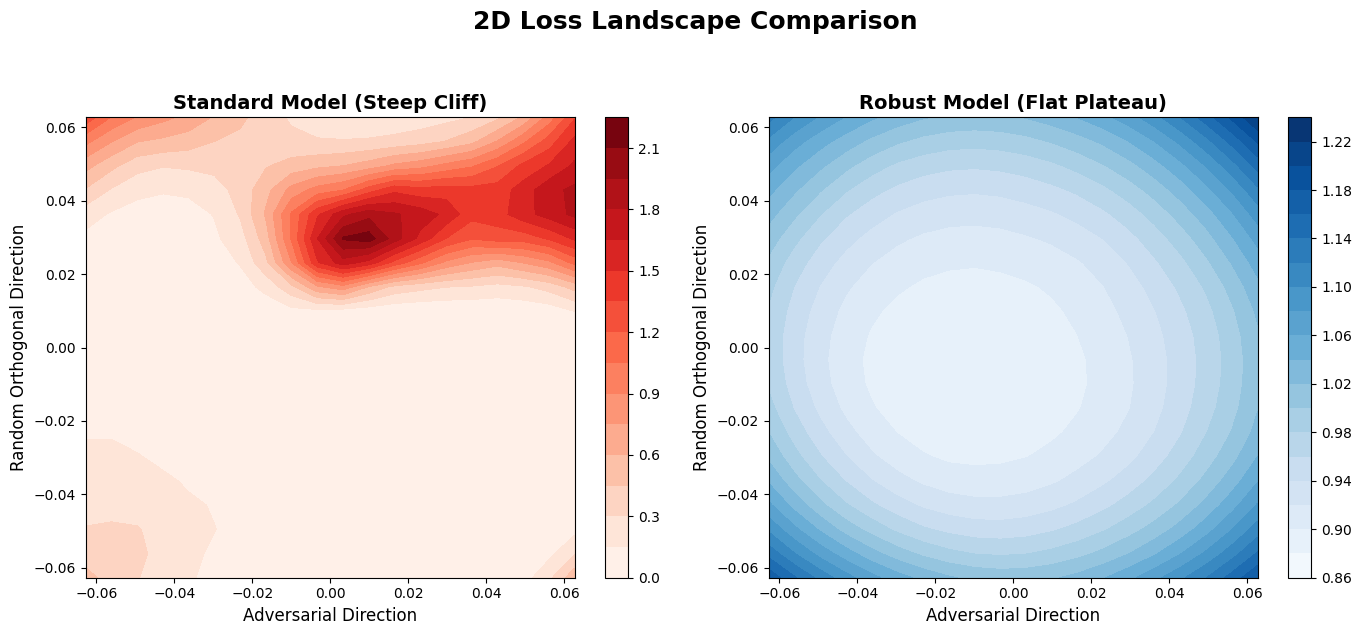

[*] Saved to loss_landscape_comparison.png!


In [16]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from models.classifier import get_cifar10_resnet18
from utils.dataset import get_dataloaders

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load Both Models
model_std = get_cifar10_resnet18(num_classes=10).to(DEVICE)
model_std.load_state_dict(torch.load("/kaggle/working/resnet18_standard_cifar10.pt"))
model_std.eval()

model_rob = get_cifar10_resnet18(num_classes=10).to(DEVICE)
model_rob.load_state_dict(torch.load("/kaggle/working/resnet18_robust_pgd_cifar10.pt"))
model_rob.eval()

# 2. Get a single image and label
_, test_loader = get_dataloaders(batch_size=1)
images, labels = next(iter(test_loader))
img, label = images.to(DEVICE), labels.to(DEVICE)
criterion = nn.CrossEntropyLoss()

print("[*] Generating Loss Landscapes... (This takes a moment to map the grid)")

# 3. Find the Adversarial Direction (X-axis)
img.requires_grad = True
loss = criterion(model_std(img), label)
loss.backward()
d1 = img.grad.detach().sign() # Fast Gradient Sign direction
img.requires_grad = False

# 4. Generate an Orthogonal Random Direction (Y-axis) via Gram-Schmidt
d2 = torch.randn_like(d1)
# Projection of d2 onto d1
proj = (torch.sum(d2 * d1) / torch.sum(d1 * d1)) * d1
d2 = d2 - proj # Make it orthogonal
d2 = d2 / torch.norm(d2) * torch.norm(d1) # Scale it to have the same magnitude as d1

# 5. Define the Grid (Scanning from -epsilon to +epsilon)
EPSILON = 8 / 255
GRID_SIZE = 20 # 20x20 grid (400 forward passes per model)
alphas = np.linspace(-EPSILON * 2, EPSILON * 2, GRID_SIZE)
betas = np.linspace(-EPSILON * 2, EPSILON * 2, GRID_SIZE)

loss_surface_std = np.zeros((GRID_SIZE, GRID_SIZE))
loss_surface_rob = np.zeros((GRID_SIZE, GRID_SIZE))

# 6. Map the Terrain
with torch.no_grad():
    for i, alpha in enumerate(alphas):
        for j, beta in enumerate(betas):
            # Perturb the image: x' = x + alpha*d1 + beta*d2
            perturbed_img = img + (alpha * d1) + (beta * d2)
            perturbed_img = torch.clamp(perturbed_img, 0, 1)
            
            # Calculate loss for Standard Model
            out_std = model_std(perturbed_img)
            loss_surface_std[i, j] = criterion(out_std, label).item()
            
            # Calculate loss for Robust Model
            out_rob = model_rob(perturbed_img)
            loss_surface_rob[i, j] = criterion(out_rob, label).item()

# 7. Plotting the Contours
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Standard Model Plot
C1 = ax1.contourf(alphas, betas, loss_surface_std, levels=20, cmap='Reds')
fig.colorbar(C1, ax=ax1)
ax1.set_title("Standard Model (Steep Cliff)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Adversarial Direction", fontsize=12)
ax1.set_ylabel("Random Orthogonal Direction", fontsize=12)

# Robust Model Plot
C2 = ax2.contourf(alphas, betas, loss_surface_rob, levels=20, cmap='Blues')
fig.colorbar(C2, ax=ax2)
ax2.set_title("Robust Model (Flat Plateau)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Adversarial Direction", fontsize=12)
ax2.set_ylabel("Random Orthogonal Direction", fontsize=12)

plt.suptitle("2D Loss Landscape Comparison", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig("/kaggle/working/loss_landscape_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("[*] Saved to loss_landscape_comparison.png!")